# Generating Samples from Trained Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Generate samples from trained models
- Sample from latent space
- Control generation process
- Evaluate generated samples
- Apply to different domains

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 05 "Sampling and Point Estimation" (drawing from a distribution) and Course 10 — Unit 1, lessons 04-05, whose trained VAE and GAN are the distributions being drawn from.

**Used later in:** Course 10 — Unit 1, lesson 12, which explores the latent space these samples come from.

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Generating samples from trained generative models

---

## Introduction

**Generating samples** from trained generative models involves sampling from learned distributions to create new data instances.

---

## 🌍 Why this lesson exists — the sampler that changed the headline number

Brock, Donahue & Simonyan (2019, BigGAN, arXiv 1809.11096) reported reaching **Inception Score 166.5 and FID 7.4** on 128×128 ImageNet, against previous bests of 52.52 and 18.6. They also introduced the **truncation trick** — and stated plainly that it "allows fine control over the trade-off between sample fidelity and variety". The same trained weights therefore produce different published headline numbers depending only on how you sample them. Sampling is not a postscript to training; it is a second set of decisions with its own trade-offs.

**What goes wrong without this:** a trained generator is not a product. Handed to a user with default random sampling, the same weights are an uncontrollable slot machine; with the right sampling strategy they are a tool. Teams that treat "the model" as the deliverable ship the slot machine.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: roadmap cell — name the sampling strategies (random, conditional,
# interpolation, truncation) that the hands-on cells below demonstrate.
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported!")
print("\nGenerating Samples from Trained Models")
print("=" * 60)


# The universal inference recipe every trained generator shares.
print("\nSampling Process:")
print("  - Sample from latent space")
print("  - Pass through generator")
print("  - Generate output")
print("  - Post-process if needed")


# Different ways to choose z — each gives a different kind of control.
print("\nSampling Strategies:")
print("  - Random sampling")
print("  - Conditional sampling")
print("  - Interpolation")
print("  - Truncation")

print("\nApplications:")
print("  - Image generation")
print("  - Text generation")
print("  - Data augmentation")
print("  - Creative applications")

print("\n✅ Sample generation concepts understood!")

✅ Libraries imported!

Generating Samples from Trained Models

Sampling Process:
  - Sample from latent space
  - Pass through generator
  - Generate output
  - Post-process if needed

Sampling Strategies:
  - Random sampling
  - Conditional sampling
  - Interpolation
  - Truncation

Applications:
  - Image generation
  - Text generation
  - Data augmentation
  - Creative applications

✅ Sample generation concepts understood!


## 🌍 Real-World Worked Example — GAN Generating Handwritten Digits

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a small **fully-connected GAN** to generate handwritten digit images from pure noise (a real DCGAN adds convolutional layers — see the references).

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


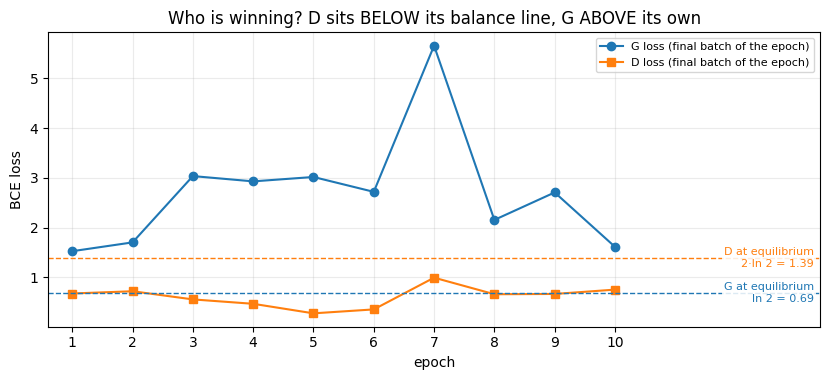


D loss averaged over the 10 epochs: 0.62  (balance point 1.39)
G loss averaged over the 10 epochs: 2.71  (balance point 0.69)
D below its line and G above its own means the discriminator is winning:
it still tells these fakes from real digits. That is the state the sample
quality in the next figure reflects — not a bug, just an under-trained G.


In [2]:
# WHAT/WHY: train the complete GAN loop on MNIST for 10 CPU epochs — this is
# the trained model whose SAMPLING the rest of the lesson explores. The figure
# below is the training record, not a sample grid: the samples appear in the
# next cell, where three sampling strategies can be compared side by side on
# these same weights.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Data: MNIST scaled to [-1, 1] to match the generator's Tanh output ────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
# Two separate optimizers — G and D are adversaries, updated in turn.
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

# Record each epoch's final losses so we can see the adversarial balance.
d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Plot the losses this loop recorded, against the game's equilibrium ────
# If the discriminator genuinely could not tell real from fake it would output
# 0.5 for everything, giving loss_G = -ln(0.5) = ln 2 = 0.69 and
# loss_D = 2*ln 2 = 1.39 (D's loss here is the SUM of its two BCE terms).
# Those two lines are the balance point; where the curves sit relative to them
# says who is winning, which is what the sample quality below depends on.
G.eval()
epochs_axis = range(1, len(d_losses) + 1)
fig, ax = plt.subplots(figsize=(8.4, 3.9))
ax.plot(epochs_axis, g_losses, 'o-', color='tab:blue',   label='G loss (final batch of the epoch)')
ax.plot(epochs_axis, d_losses, 's-', color='tab:orange', label='D loss (final batch of the epoch)')
ref_box = dict(fc='white', ec='none', alpha=0.85, pad=1.5)
ax.axhline(np.log(2),     color='tab:blue',   ls='--', lw=1)
ax.axhline(2 * np.log(2), color='tab:orange', ls='--', lw=1)
# Extra right margin so the two reference labels sit in empty space rather
# than on top of the epoch-10 data points.
ax.set_xlim(0.6, len(d_losses) + 3.4)
ax.text(len(d_losses) + 3.3, np.log(2),     "G at equilibrium\nln 2 = 0.69",  fontsize=8,
        color='tab:blue',   va='center', ha='right', bbox=ref_box)
ax.text(len(d_losses) + 3.3, 2 * np.log(2), "D at equilibrium\n2·ln 2 = 1.39", fontsize=8,
        color='tab:orange', va='center', ha='right', bbox=ref_box)
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss'); ax.set_xticks(list(epochs_axis))
ax.set_title('Who is winning? D sits BELOW its balance line, G ABOVE its own')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"\nD loss averaged over the 10 epochs: {np.mean(d_losses):.2f}  (balance point 1.39)")
print(f"G loss averaged over the 10 epochs: {np.mean(g_losses):.2f}  (balance point 0.69)")
print("D below its line and G above its own means the discriminator is winning:")
print("it still tells these fakes from real digits. That is the state the sample")
print("quality in the next figure reflects — not a bug, just an under-trained G.")

**Read the curves against the two dashed lines.** Those lines are not drawn by eye: they are where this game ends when the discriminator genuinely cannot tell a real digit from a generated one and answers 0.5 to everything — G's loss ln 2 = 0.69, D's loss 2·ln 2 = 1.39.

Neither curve is on its line, and both miss in the same direction: **D sits below 1.39 for almost every epoch while G sits well above 0.69**, spiking past 5 at epoch 7. Read together, that is one statement — the discriminator is winning. It is still catching these fakes, which is precisely why the samples in the next figure are rough rather than convincing.

This matters for the whole lesson. Everything below changes *how you sample* these weights, and none of it can change what the curves above are telling you: the generator has not yet learned to produce a digit that fools its own critic. Sampling strategies redistribute the outputs of a fixed generator — they cannot move these lines.

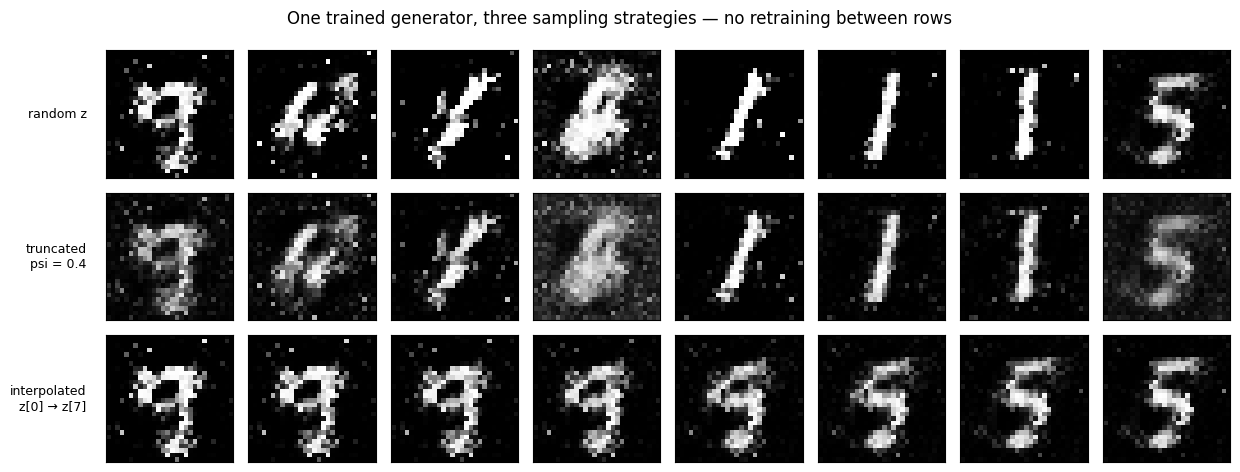

strategy                      diversity (mean pairwise pixel distance)
random z                      18.12
truncated (psi=0.4)           14.06
interpolated z[0] -> z[7]     8.94

Same weights, same eight latent vectors — only the CHOICE of z differs.


In [3]:
# WHAT/WHY: the roadmap at the top listed four sampling strategies. Three of
# them need no retraining at all — they are different ways of CHOOSING z for
# the generator we just trained. Here are those three on one figure, from the
# same weights, so the difference is visible rather than described.
snap_rng = torch.Generator().manual_seed(11)      # own stream: keeps this reproducible
z_base   = torch.randn(8, LATENT_DIM, generator=snap_rng)
PSI      = 0.4                                    # truncation strength

with torch.no_grad():
    row_random = G(z_base).view(-1, 28, 28)                    # 1. random sampling
    row_trunc  = G(PSI * z_base).view(-1, 28, 28)              # 2. truncated sampling
    alphas     = torch.linspace(0, 1, 8).view(-1, 1)           # 3. interpolation
    z_path     = (1 - alphas) * z_base[0:1] + alphas * z_base[7:8]
    row_interp = G(z_path).view(-1, 28, 28)

rows = [("random z", row_random), (f"truncated (psi={PSI})", row_trunc),
        ("interpolated z[0] -> z[7]", row_interp)]
# Short two-line labels, written horizontally in the left margin: a long
# vertical label on a short row gets clipped by the figure edge.
row_labels = ["random z", f"truncated\npsi = {PSI}", "interpolated\nz[0] → z[7]"]
fig, axes = plt.subplots(3, 8, figsize=(12.5, 4.8))
for r, (name, imgs) in enumerate(rows):
    for c in range(8):
        axes[r, c].imshow(imgs[c], cmap='gray', vmin=-1, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(row_labels[r], fontsize=9, rotation=0,
                          ha='right', va='center', labelpad=14)
plt.suptitle("One trained generator, three sampling strategies — no retraining between rows")
plt.tight_layout(); plt.show()

# ── Put a number on what each strategy costs or buys ─────────────────────
print("strategy                      diversity (mean pairwise pixel distance)")
for name, imgs in rows:
    d = torch.pdist(imgs.reshape(len(imgs), -1)).mean().item()
    print(f"{name:<28}  {d:.2f}")
print("\nSame weights, same eight latent vectors — only the CHOICE of z differs.")

**Read the three rows as three product decisions taken after training was over.** The weights are identical in every row; only the rule for choosing `z` changed.

**Row 1 (random)** is the default: eight independent draws from N(0, I). It gives the widest spread of outputs — and the widest spread of *quality*. Some panels are clean digits, one is an unreadable smudge, and three of the eight are variations on a 1. That is what "an uncontrolled sample" looks like.

**Row 2 (truncated)** feeds the *same* eight latents scaled by ψ = 0.4, pulling each one toward the centre of the prior. Compare column by column: the shapes survive but come out dimmer and mushier, and the measured diversity drops from 18.12 to 14.06. The cost is exactly as example 07 predicts. The benefit is not: truncation improves samples only when the generator's *average* output is itself a good sample, which is true of BigGAN and StyleGAN and plainly not true of a fully-connected GAN trained for ten CPU epochs. Read that as the honest scope of the trick, not as a failure of the experiment.

**Row 3 (interpolation)** is not eight samples at all — it is a single path from the first latent to the last, so neighbouring panels are *meant* to resemble each other as one digit turns into another. Its diversity number (8.94) measures the length of a walk, not the variety of a sample, and comparing it with the rows above would be a category error.

That is the lesson in one figure: three genuinely different behaviours out of one file of weights, and one number that means something different in each row. It also shows the limit stated below — nothing in any row is something the generator did not already know how to produce. Sampling selects; it does not add.

## 💬 Discuss

1. Our GAN trained for 10 epochs and the samples are rough. Name a strategy from the roadmap above that could improve their *apparent* quality without any retraining — and state exactly what it costs.
2. A client asks for "16 *different* digits". Random sampling cannot promise that. Which strategy can — and what must have been true at **training** time for it to be available?
3. Brock et al. report Inception Score and FID moving in opposite directions as truncation changes. If your contract specifies "FID below 20", is tuning the sampler until you hit it engineering or cheating? Where is the line, and what would you disclose?


## ⚠️ Where this breaks

**Sampling cannot add what training left out.** Truncation, top-k and conditioning all *select* from what the generator already produces. None of them can create a mode the model never learned, and none of them will repair a mode-collapsed generator.

**Every control that improves typicality removes diversity.** There is no setting that buys both — that trade *is* the truncation trick, and example 07 measures it (diversity 17.03 → 11.64 as ψ goes 1.0 → 0.3).

**This model only supports one of the four strategies.** Conditional sampling requires labels at *training* time (example 06); interpolation requires a latent space with structure worth walking (example 12). An unconditional GAN trained on noise gives you random sampling and truncation, and that is all.

**Do not read the sample grid as a quality report.** Sixteen images chosen by one random draw is the weakest evidence in this course. Example 10's Fréchet distance exists because grids are unfalsifiable.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

The four strategies in the roadmap above are still the vocabulary; for a diffusion or flow model the dials are
different ones. You pick a solver and a number of integration steps, and you set a **guidance scale** — the
direct descendant of the truncation factor you used here, spending diversity to buy fidelity to the condition.
Sampling *cost* then became the headline engineering problem, and the answer was distillation: compress a
many-step teacher into a one-step or few-step student that matches it in distribution rather than trajectory.
DMD2 reports FID 1.28 on ImageNet-64×64 with a 500× reduction in inference cost, and gets there partly by
folding a GAN loss into the distillation so the student also sees real images (Yin *et al.* 2024) — on top of
formulations whose noise-to-data paths are straight enough to integrate cheaply in the first place (Esser
*et al.* 2024).

**Why this lesson is still exactly the right thing to learn.** Everything you established here survives the
change unaltered: a trained generator is a fixed function of a latent; sampling is a *product* decision taken
after training is over, with no retraining and no new data; and — as ⚠️ says — no sampling rule can add a mode
that training left out. That last sentence is as true of a four-step distilled flow model as of the ten-epoch
GAN you trained above, and it is the point the official plan examines.

**Read:** Yin *et al.* (2024), <https://arxiv.org/abs/2405.14867> · Esser *et al.* (2024),
<https://arxiv.org/abs/2403.03206> (both listed below).

---

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- DALL·E 2 and Midjourney are **diffusion** systems, not GANs — what carries over from this notebook is the sampling machinery (a latent drawn, a network decoding it, a truncation-style dial), not the adversarial loop. Diffusion itself is taught in Unit 3.
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors

**Recent (2024–2026) — sampling as the engineering problem:**
- Esser et al. (2024) — [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) *(when noise and data are connected by a straight line, sampling becomes "which solver, how many steps")*
- Yin et al. (2024) — [Improved Distribution Matching Distillation for Fast Image Synthesis](https://arxiv.org/abs/2405.14867) *(DMD2 — distilling a many-step teacher into a one-step student; reports FID 1.28 on ImageNet-64×64 with a 500× reduction in inference cost)*


## 📝 Summary

In **11 — Generating Samples from Trained Models** you reviewed the four sampling strategies (random, conditional, interpolation, truncation) and ran the full pipeline hands-on: latent noise → trained generator → digit images. Each strategy has its own hands-on lesson: conditional sampling in example 06, the truncation trick in example 07, and interpolation in example 12.